# Introducción a los algoritmos genéticos (Optimización)

In [2]:
import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
from matplotlib import cm
import matplotlib.pyplot as plt 

Text(0.5, 0, 'f(x, y)')

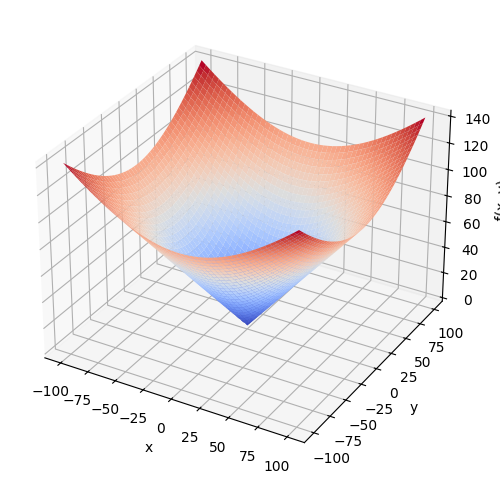

In [4]:
# Definimos la funcion objetivo
def funcion_prueba(x):
    res = np.sqrt(x[0] ** 2 + x[1] ** 2)
    return res

# Se generan vectores que borran todo el dominio
x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

# Se evalua todos los valores de las variables 
x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_ [x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

# Representamos los resultados obtenidos
figure_3d = plt.figure(figsize = (8, 6))
ax = figure_3d.add_subplot(111, projection = "3d")

ax.plot_surface(x_ax, y_ax, fx, cmap = cm.coolwarm)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")


In [14]:
# Creacion del problema
creator.create("FitnessMax", base.Fitness, weights = (1.0, ))

c:\Users\migue\OneDrive\Escritorio\Ingenieria en tecnologias de la información\Octavo semestre\.venv\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [15]:
# Creacion del individuo
creator.create("Individual", list, fitness = creator.FitnessMax)

c:\Users\migue\OneDrive\Escritorio\Ingenieria en tecnologias de la información\Octavo semestre\.venv\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [16]:
# Crear individuos aleatorios
toolbox = base.Toolbox() # Creacion de individuos aleatorios para crear la poblacion inicial

# Generacion de genes 
toolbox.register("attr_uniform", random.uniform, -100, 100)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform, 2)

# Se crea la poblacion inicial
toolbox.register("population", tools.initRepeat, list, toolbox.individual, 10)

In [21]:
# Definicio de la funcion objetivo
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0] ** 2 + x[1] ** 2)
    return res,

# Aplicacion del fitness
toolbox.register("evaluate", funcion_objetivo)

In [22]:
# Operadores geneticos
toolbox.register("mate", tools.cxOnePoint)
'''
mu: La media
sigma: Desviación tipica
indpb: Probabilidad de que un gen mute
'''
toolbox.register("mutate", tools.mutGaussian, mu = 0, sigma = 5, indpb = 0.1)
toolbox.register("select", tools.selTournament, tournsize = 3)

In [23]:
# Convergencia del algoritmo 
def plot_evolucion(log):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype = float)
    fit_maxs = np.array(log.select("max"), dtype = float)
    fit_ave = np.array(log.select("avg"), dtype = float)

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs, where = where_mask, facecolor = 'g', alpha = 0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(["Min", "Max", "Avg"], loc = "lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps", dpi = 300)

gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779
Mejor fitness: 136.778896
Mejor individuo: [-94.692806

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


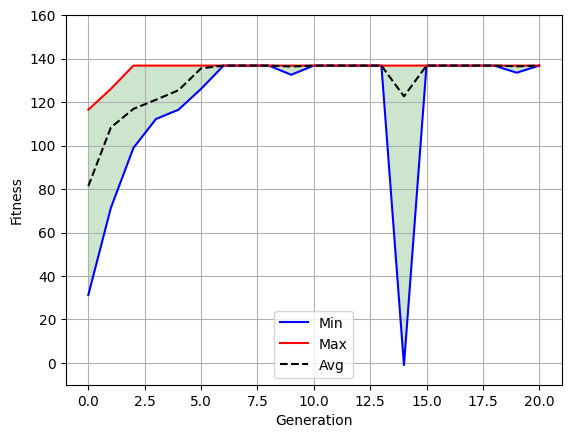

In [24]:
# Configuracion del algoritmo genetico
def main():
    random.seed(42) # Semilla del generadore de los numeros pseudoaleatorios
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20 # Probabilidades de cruza, mutacion y numero de generaciones
    pop = toolbox.population() # Generacion de la poblacion inicial
    hof = tools.HallOfFame(1) # Almacena al mejor individuo encontrado en todas las generaciones
    stats = tools.Statistics(lambda ind: ind.fitness.values) # Genera las estadisticas de población sobre el fitness
    stats.register("avg", np.mean) # Calcular la media
    stats.register("std", np.std) # Desviación estandar tipica
    stats.register("min", np.min) # Valor minimo absoluto de la generación
    stats.register("max", np.max) # Valor maximo absoluto de la generación
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb = CXPB, mutpb = MUTPB, ngen = NGEN, stats = stats, halloffame = hof, verbose = True)
    return hof, logbook

if __name__ == "__main__":
    best, log = main()
    print("Mejor fitness: %f" %best[0].fitness.values)
    print("Mejor individuo: %s" %best[0])
    plot_evolucion(log)